### Trasformation 

\begin{equation}
E: (a, e, M, w)  \rightarrow X: (x,y,v_x, v_y)
\end{equation}

\begin{equation}
    \mathbb{J}_{X o E} =
    \begin{pmatrix} 
    \partial_ax & \partial_ex & \partial_wx & \partial_Mx\\
    \partial_ay & \partial_ey & \partial_wy & \partial_My \\
    \partial_av_x & \partial_ev_x & \partial_wv_x & \partial_Mv_x \\
    \partial_av_y & \partial_ev_y & \partial_wv_y & \partial_Mv_y 
    \end{pmatrix}
\end{equation}

In [1]:
import numpy as np
from Utils import CanonicalUnits, calcKeplerianJacobians, JaccobianComponents, Kepler, GravitationalParameters, X2E, computeNumericalJacobian, OrbitTrasformations
import spiceypy as spy
import scipy.optimize as optimize
from tqdm import tqdm
from typing import Dict, Set, Optional, Union, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
%load_ext autoreload 
%autoreload 2

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

In [3]:
def compute_functions(i: float, w: float, Omega: float, 
                    which: Set[str]) -> Dict[str, float]:
    """Compute transformation functions A, B, C, D, F, G"""
    results = {}
    
    if 'A' in which:
        results['A'] = (np.cos(Omega)*np.cos(w) - np.sin(Omega)*np.cos(i)*np.sin(w))
    if 'B' in which:
        results['B'] = (-np.cos(Omega)*np.sin(w) - np.sin(Omega)*np.cos(i)*np.cos(w))
    if 'C' in which:
        results['C'] = (np.sin(Omega)*np.cos(w) + np.cos(Omega)*np.cos(i)*np.sin(w))
    if 'D' in which:
        results['D'] = (-np.sin(Omega)*np.sin(w) + np.cos(Omega)*np.cos(i)*np.cos(w))
    
    return results

def compute_state_vector(E: np.array, mu: float) -> np.array:
    state_vector = spy.conics(E+[0, mu], 0)
    return state_vector

def jacobian_XoE(a: float, e: float, w: float, M: float, mu: float) -> np.array:
    i = 0
    Omega = 0
    E = optimize.newton(Kepler, M, args=(M, e))

    functions = compute_functions(i, w, Omega, {'A', 'B', 'C', 'D'})
    A = functions['A']
    B = functions['B']
    C = functions['C']
    D = functions['D']
    
    ot = OrbitTrasformations()
    r = ot.r(a, e, E)
    eps = ot.sqrt_e(e)
    nu = ot.nu(a, mu)
    nur = nu/r

    q = a*(1-e)
    state_vector = compute_state_vector([q, e, i, Omega, w, M], mu)

    #partial a

    partial_a_x = state_vector[0]/a
    partial_a_y = state_vector[1]/a
    partial_a_vx = -state_vector[3]/(2*a)
    partial_a_vy = -state_vector[4]/(2*a)

    partial_a = [partial_a_x, partial_a_y, partial_a_vx, partial_a_vy]

    #partial e

    #dX/de
    dcosEde=-a*np.sin(E)**2/r       
    dsinEde=a*np.cos(E)*np.sin(E)/r
    dnurde=(nu*a/r**2)*(np.cos(E)-(a/r)*e*np.sin(E)**2)
    depsde=-e/eps

    drAde=a*(dcosEde-1)
    drBde=a*(depsde*np.sin(E)+eps*dsinEde)

    dvAde=-(dnurde*np.sin(E)+nur*dsinEde)
    dvBde=(dnurde*eps*np.cos(E)+nur*depsde*np.cos(E)+nur*eps*dcosEde)

    partial_e = np.array([
        drAde*A+drBde*B,
        drAde*C+drBde*D,
        dvAde*A+dvBde*B,
        dvAde*C+dvBde*D
    ])

    #partial w

    partial_w_x = -state_vector[1]*np.cos(i) - state_vector[2]*np.sin(i)*np.cos(Omega)
    partial_w_y = state_vector[0]*np.cos(i) - state_vector[2]*np.sin(i)*np.sin(Omega)
    partial_w_vx = -state_vector[4]*np.cos(i) - state_vector[5]*np.sin(i)*np.cos(Omega)
    partial_w_vy = state_vector[3]*np.cos(i) - state_vector[5]*np.sin(i)*np.sin(Omega)

    partial_w = [partial_w_x, partial_w_y, partial_w_vx, partial_w_vy]

    #partial M
    n = (mu/a**3)**0.5
    factor = -(mu*a**3)**0.5/r**3

    partial_M_x = (1/n) * state_vector[3]
    partial_M_y = (1/n) * state_vector[4]
    partial_M_vx = factor * state_vector[0]
    partial_M_vy = factor * state_vector[1]

    partial_M = [partial_M_x, partial_M_y, partial_M_vx, partial_M_vy]

    J = np.zeros((4,4))
    J[:,0] = partial_a
    J[:,1] = partial_e
    J[:,2] = partial_w
    J[:,3] = partial_M
    
    return J


In [4]:
a = 0.5
e = 0.1
i = 0
Omega = 0
w = np.pi/2
M = np.pi
q = a*(1-e)

J = jacobian_XoE(a,e,w,M,mu)

Je2c=np.eye(4)
Je2c[0,0]=1/(1-e)
Je2c[0,1]=q/(1-e)**2
Jq=np.matmul(J,Je2c)
Jq

array([[ 2.34912103e-15,  1.20548516e-15,  5.50000000e-01,
         4.52267017e-01],
       [-1.22222222e+00, -1.11111111e+00,  1.05710446e-15,
         9.25934527e-16],
       [-8.93172099e+00, -1.25856068e+01, -1.64574680e-14,
        -1.41163557e-14],
       [-1.82860756e-14, -6.84694175e-15,  8.03854889e+00,
         7.34458692e+00]])

In [5]:
E = [q, e, 0, 0, w, M]
E2X = lambda E, mu: spy.conics(E+[0, mu], 0)
dX=np.array([1e-3]*6)
args=dict(mu=mu)
E_num, JXoE=computeNumericalJacobian(E2X,E,dX,**args)
JXoE

array([[-1.36877367e-13, -2.72639618e-13,  0.00000000e+00,
         5.49999908e-01,  5.49999908e-01,  4.52266960e-01],
       [-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.11022302e-13],
       [ 0.00000000e+00,  0.00000000e+00, -5.49999908e-01,
         0.00000000e+00,  0.00000000e+00, -0.00000000e+00],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-3.59016386e-12, -1.79957317e-12,  0.00000000e+00,
         8.03854755e+00,  8.03854755e+00,  7.34458628e+00],
       [-0.00000000e+00,  0.00000000e+00,  5.69401612e-15,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [6]:
Jcomp = np.zeros((4,4))
Jcomp[0,0] = JXoE[0,0]
Jcomp[0,1] = JXoE[0,1]
Jcomp[0,2] = JXoE[0,4]
Jcomp[0,3] = JXoE[0,5]
Jcomp[1,0] = JXoE[1,0]
Jcomp[1,1] = JXoE[1,1]
Jcomp[1,2] = JXoE[1,4]
Jcomp[1,3] = JXoE[1,5]
Jcomp[2,0] = JXoE[3,0]
Jcomp[2,1] = JXoE[3,1]
Jcomp[2,2] = JXoE[3,4]
Jcomp[2,3] = JXoE[3,5]
Jcomp[3,0] = JXoE[4,0]
Jcomp[3,1] = JXoE[4,1]
Jcomp[3,2] = JXoE[4,4]
Jcomp[3,3] = JXoE[4,5]
Jcomp


array([[-1.36877367e-13, -2.72639618e-13,  5.49999908e-01,
         4.52266960e-01],
       [-1.22222222e+00, -1.11111248e+00,  0.00000000e+00,
        -1.11022302e-13],
       [-8.93174855e+00, -1.25856115e+01,  0.00000000e+00,
         0.00000000e+00],
       [-3.59016386e-12, -1.79957317e-12,  8.03854755e+00,
         7.34458628e+00]])

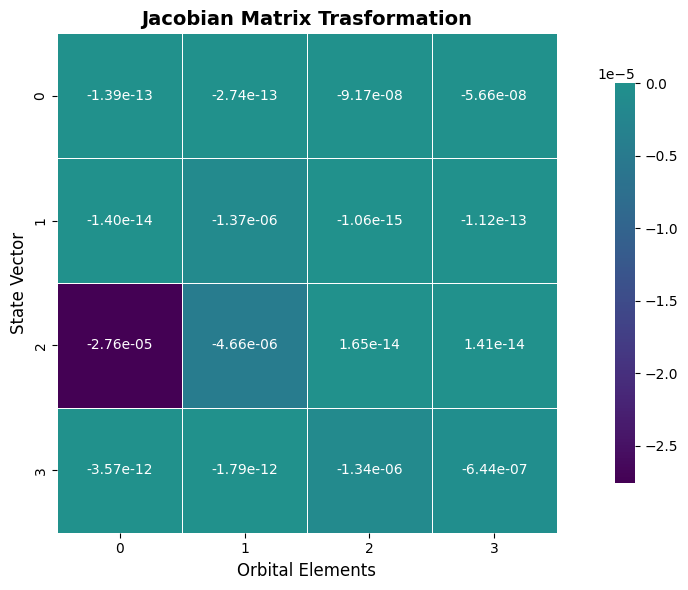

In [7]:
plt.figure(figsize=(12, 6))

# Create heatmap
sns.heatmap(Jcomp - Jq, 
            annot=True, 
            fmt='.2e', 
            cmap='viridis', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title(f'Jacobian Matrix Trasformation', fontsize=14, fontweight='bold')
plt.xlabel('Orbital Elements', fontsize=12)
plt.ylabel('State Vector', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
def trasformation_aewE_to_xyvxvy(a: float, e: float, w: float, M: float, mu: float) -> tuple[float, float, float, float]:
    Omega = 0
    i = 0
    q = a*(1-e)

    state_vec = compute_state_vector([q, e, i, Omega, w, M], mu)
    x = state_vec[0]
    y = state_vec[1]
    vx = state_vec[3]
    vy = state_vec[4]

    return x, y, vx, vy

def trasformation_xyvxvy_to_aewE(x: float, y: float, vx: float, vy: float, mu: float) -> tuple[float, float, float, float]:

    elements = spy.oscelt([x, y, 0, vx, vy, 0], et=0, mu=mu)
    q = elements[0]
    e = elements[1]
    w = elements[4]
    M = elements[5]
    a = q/(1-e)

    return a, e, w, M

In [9]:
N = int(1e5)

a_uniform = np.random.uniform(0, 2, N)
e_uniform = np.random.uniform(0, 1, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)
q_uniform = a_uniform*(1-e_uniform)

x_uniform, y_uniform, vx_uniform, vy_uniform = trasformation_aewE_to_xyvxvy(a_uniform[0], e_uniform[0], w_uniform[0], M_uniform[0], mu)
x_uniform, y_uniform, vx_uniform, vy_uniform

(-0.9105445270349357,
 -0.34418099257225393,
 3.01185409918355,
 -5.368026245054574)

In [10]:
a_inverse, e_inverse, w_inverse, M_inverse = trasformation_xyvxvy_to_aewE(x_uniform, y_uniform, vx_uniform, vy_uniform, mu)
a_inverse, e_inverse, w_inverse, M_inverse 

(0.9130974924177135, 0.16301211472234828, 5.636019297485812, 4.444120596926791)

In [11]:
jacobian_XoE(q_uniform[1], e_uniform[1], w_uniform[1], M_uniform[1], mu)

array([[-1.36539806, -0.14547709, -0.34284886, -0.04090058],
       [ 1.1971118 ,  0.2678626 , -0.39104549, -0.08151229],
       [ 2.92763705,  7.02890606,  3.34201827,  2.6776749 ],
       [ 5.83459649,  8.96676554, -1.67693114, -2.3476496 ]])

In [12]:
xyvxvy = np.zeros((N, 4))

for el in tqdm(range(N)):
    a = a_uniform[el]
    e = e_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]

    x, y, vx, vy = trasformation_aewE_to_xyvxvy(a, e, w, M, mu)
    xyvxvy[el] = np.array([x, y, vx, vy])

100%|██████████| 100000/100000 [00:01<00:00, 78235.49it/s]


In [13]:
xyvxvy

array([[-9.10544527e-01, -3.44180993e-01,  3.01185410e+00,
        -5.36802625e+00],
       [-2.28390962e+00,  2.00241616e+00, -6.93888055e-01,
        -1.38287525e+00],
       [ 5.72747620e-01, -1.52532604e-01,  3.33793082e+00,
         8.40974887e+00],
       ...,
       [ 1.84664253e+00,  2.37871555e+00, -3.60179792e-01,
         8.96739280e-01],
       [-3.02610545e-01, -8.01668851e-02,  4.20749504e+00,
        -1.43723605e+01],
       [ 2.60986331e-02,  2.68869744e-02, -2.19245867e+01,
         3.15710859e+01]])

In [14]:
def P_aewM() -> float:
    a_max = 2; a_min = 0
    e_max = 1; e_min = 0
    w_max = 2*np.pi; w_min = 0
    M_max = 2*np.pi; M_min = 0
    return 1/(a_max - a_min) * 1/(e_max - e_min) * 1/(w_max - w_min) * 1/(M_max - M_min)

def P_xyvxvy(x: float, y: float, vx: float, vy: float) -> float:
    a, e, w, M = trasformation_xyvxvy_to_aewE(x, y, vx, vy, mu)
    J = jacobian_XoE(a,e,w,M,mu)
    #det = np.linalg.det(J)
    det = 1.0/np.linalg.det(J)
    P = P_aewM() * abs(det)
    return P

def P_xyvxvy_vectorized(x: np.array, y: np.array, vx: np.array, vy: np.array, mu: float) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    vx = np.asarray(vx)
    vy = np.asarray(vy)

    # Prepare output array
    shape = np.broadcast(x, y, vx, vy).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()

    for idx in range(x_flat.size):
        a, e, w, M = trasformation_xyvxvy_to_aewE(x_flat[idx], y_flat[idx], vx_flat[idx], vy_flat[idx], mu)
        J = jacobian_XoE(a,e,w,M,mu)
        #det = np.linalg.det(J)/(1-e)
        det = 1.0/np.linalg.det(J)
        P.flat[idx] = P_aewM() * abs(det)

    return P.reshape(shape)


## Probabilidad en un hipercubo

In [15]:
def surface_integral_P_xyvxvy(center, widths, n_points=8, mu=1):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, vx0, vy0 = center
    dx, dy, dvx, dvy = widths

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts

    # Create meshgrid of all quadrature points
    X, Y, VX, VY = np.meshgrid(x_pts, y_pts, vx_pts, vy_pts, indexing='ij')
    WX, WY, WVX, WVY = np.meshgrid(wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    WF = (WX * WY * WVX * WVY).ravel()

    # Evaluate P at all points
    Pf = P_xyvxvy_vectorized(Xf, Yf, VXf, VYf, mu)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dvx) * (0.5*dvy)
    return integral

In [16]:
# Example: Compare theoretical (integral) and numerical (count) number of objects in a phase-space volume

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
v_x = 0
v_y = (mu/1)**0.5

dxy = 0.5
dvxy = 5000 * (1/AU_m) * year

center = (c_x, c_y, v_x, v_y)
widths = (dxy, dxy, dvxy, dvxy)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_xyvxvy(center, widths, n_points=8, mu=mu)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

# Numerical: count number of objects in the volume from the sample
objsx = (abs(xyvxvy[:,0] - c_x) <= dxy/2) 
objsy = (abs(xyvxvy[:,1] - c_y) <= dxy/2) 
objsvx = (abs(xyvxvy[:,2] - v_x) <= dvxy/2) 
objsvy = (abs(xyvxvy[:,3] - v_y) <= dvxy/2) 

objects = objsx & objsy & objsvx & objsvy
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')

Theoretical (integral) number of objects in volume: 117.75825215646434
Numerical (count) number of objects inside volume: 123


In [17]:
(N_theoretical * N)/N_numeric

0.9573841638736938

## Probabilidad en circulo para x,y y cuadrado para vx, vy

In [18]:
def integral_P_xyvxvy_circle_box(center_xy, r, center_vxvy, dvx, dvy, n_points_r=8, n_points_theta=16, n_points_vx=8, n_points_vy=8, mu=1):
    """
    Computes the integral of P_xyvxvy in a circle for x, y (center center_xy, radius r)
    and in a box for vx, vy (center center_vxvy, dimensions dvx, dvy).
    Uses Gauss quadrature for the surface integral in (x, y) and midpoint rule for (vx, vy).

    Parameters:
        center_xy: tuple (x0, y0) - center of the circle in x, y
        r: float - radius of the circle in x, y
        center_vxvy: tuple (vx0, vy0) - center of the box in vx, vy
        dvx: float - width of the box in vx
        dvy: float - width of the box in vy
        n_points_r: int - number of Gauss points in radial direction (for x, y)
        n_points_theta: int - number of Gauss points in angular direction (for x, y)
        n_points_vx: int - number of points in vx
        n_points_vy: int - number of points in vy

    Returns:
        float: The integral value
    """

    x0, y0 = center_xy
    vx0, vy0 = center_vxvy

    # Gauss-Legendre quadrature for r in [0, r]
    r_nodes, r_weights = np.polynomial.legendre.leggauss(n_points_r)
    r_grid = 0.5 * r * (r_nodes + 1)  # map from [-1,1] to [0, r]
    r_w = 0.5 * r * r_weights         # scale weights

    # Gauss-Legendre quadrature for theta in [0, 2pi]
    theta_nodes, theta_weights = np.polynomial.legendre.leggauss(n_points_theta)
    theta_grid = np.pi * (theta_nodes + 1)  # map from [-1,1] to [0, 2pi]
    theta_w = np.pi * theta_weights         # scale weights

    # Meshgrid for r and theta
    rr, tt = np.meshgrid(r_grid, theta_grid, indexing='ij')
    wr, wt = np.meshgrid(r_w, theta_w, indexing='ij')
    xx = x0 + rr * np.cos(tt)
    yy = y0 + rr * np.sin(tt)
    jac_xy = rr  # Jacobian for polar to cartesian

    # Combine weights for (r, theta)
    w_xy = (wr * wt * jac_xy).ravel()
    xx_flat = xx.ravel()
    yy_flat = yy.ravel()
    n_xy = xx_flat.size

    # Midpoint rule for vx, vy in box
    vx_grid = np.linspace(vx0 - dvx/2 + dvx/(2*n_points_vx), vx0 + dvx/2 - dvx/(2*n_points_vx), n_points_vx)
    vy_grid = np.linspace(vy0 - dvy/2 + dvy/(2*n_points_vy), vy0 + dvy/2 - dvy/(2*n_points_vy), n_points_vy)
    dvx_step = dvx / n_points_vx
    dvy_step = dvy / n_points_vy

    vx_flat = np.repeat(vx_grid, n_points_vy)
    vy_flat = np.tile(vy_grid, n_points_vx)
    n_v = vx_flat.size

    # Broadcast to all combinations
    XX = np.repeat(xx_flat, n_v)
    YY = np.repeat(yy_flat, n_v)
    W_XY = np.repeat(w_xy, n_v)
    VX = np.tile(vx_flat, n_xy)
    VY = np.tile(vy_flat, n_xy)

    # Evaluate P at all points
    P_vals = P_xyvxvy_vectorized(XX, YY, VX, VY, mu)

    # The volume element: Gauss weights for (x, y), midpoint for (vx, vy)
    dV = W_XY * dvx_step * dvy_step

    # Integral is sum(P * dV)
    integral = np.sum(P_vals * dV)
    return integral

In [19]:
c_x = 1
c_y = 0
v_x = 0
v_y = (mu/1)**0.5

dxy = 0.5
dvxy = 5000 * (1/AU_m) * year

center_xy = (c_x, c_y)
center_vxvy = (v_x, v_y)
widths_xy = (dxy, dxy)
widths_vxvy = (dvxy, dvxy)

r_circle = 5

# Count objects inside the circle in (x, y), all velocities
mask_circle = (xyvxvy[:,0] - c_x)**2 + (xyvxvy[:,1] - c_y)**2 <= r_circle**2
count_in_circle = np.sum(mask_circle)

# Count objects inside the box in (vx, vy), all positions
mask_box = (
    (xyvxvy[:,2] >= v_x - dvxy/2) & (xyvxvy[:,2] <= v_x + dvxy/2) &
    (xyvxvy[:,3] >= v_y - dvxy/2) & (xyvxvy[:,3] <= v_y + dvxy/2)
)
count_in_box = np.sum(mask_box)

# Count objects inside both the circle and the box
mask_both = mask_circle & mask_box
count_in_both = np.sum(mask_both)


# Use the provided function to calculate the theoretical integral
# integral_P_xyvxvy_circle_box should be defined elsewhere in the notebook

prob_int_both = integral_P_xyvxvy_circle_box(
    center_xy, r_circle, center_vxvy, dvxy, dvxy,
    n_points_r=20, n_points_theta=40, n_points_vx=40, n_points_vy=40, mu=mu
)

print("Numerical experiment (fraction of samples):")
print(f"  In both circle (x, y) and box (vx, vy): {count_in_both}")

print("\nIntegral of P_xyvxvy over regions (using integral_P_xyvxvy_circle_box):")
print(f"  In both: {prob_int_both * N}")

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\Utils.py:150: RuntimeWarning: invalid value encountered in scalar power
  return (1-e**2)**0.5
c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\Utils.py:154: RuntimeWarning: invalid value encountered in scalar power
  return (mu*a)**0.5
C:\Users\aguju\AppData\Local\Temp\ipykernel_18864\267637547.py:81: RuntimeWarning: invalid value encountered in scalar power
  n = (mu/a**3)**0.5
C:\Users\aguju\AppData\Local\Temp\ipykernel_18864\267637547.py:82: RuntimeWarning: invalid value encountered in scalar power
  factor = -(mu*a**3)**0.5/r**3
c:\Users\aguju\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\linalg\linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


RuntimeError: Failed to converge after 50 iterations, value is -0.10012326040779405.

## Probabilidad en circulo en x, y, pero en todas las velocidades 

In [ ]:
def surface_integral_P_xyvxvy_circle_allv(center_xy, r, n_points_r=20, n_points_theta=40, n_points_v=20, v_lim=8, mu=1):
    """
    Compute the surface integral of P_xyvxvy over a circle in (x, y) of radius r centered at center_xy,
    and over all velocities (vx, vy) from -inf to inf (approximated by [-v_lim, v_lim]).
    Uses Gauss-Legendre quadrature for all variables and the vectorized P_xyvxvy.
    """
    x0, y0 = center_xy

    # Gauss-Legendre nodes and weights for r in [0, r]
    r_nodes, r_weights = np.polynomial.legendre.leggauss(n_points_r)
    r_nodes = 0.5 * (r_nodes + 1) * r  # map from [-1,1] to [0, r]
    r_weights = 0.5 * r * r_weights

    # Gauss-Legendre nodes and weights for theta in [0, 2pi]
    theta_nodes, theta_weights = np.polynomial.legendre.leggauss(n_points_theta)
    theta_nodes = 0.5 * (theta_nodes + 1) * 2 * np.pi
    theta_weights = 0.5 * 2 * np.pi * theta_weights

    # Gauss-Legendre nodes and weights for vx, vy in [-v_lim, v_lim]
    vx_nodes, vx_weights = np.polynomial.legendre.leggauss(n_points_v)
    vx_nodes = 0.5 * (vx_nodes + 1) * 2 * v_lim - v_lim
    vx_weights = 0.5 * 2 * v_lim * vx_weights

    vy_nodes, vy_weights = np.polynomial.legendre.leggauss(n_points_v)
    vy_nodes = 0.5 * (vy_nodes + 1) * 2 * v_lim - v_lim
    vy_weights = 0.5 * 2 * v_lim * vy_weights

    # Create meshgrid for all variables
    rr, tt, vvx, vvy = np.meshgrid(r_nodes, theta_nodes, vx_nodes, vy_nodes, indexing='ij')
    rr_w, tt_w, vvx_w, vvy_w = np.meshgrid(r_weights, theta_weights, vx_weights, vy_weights, indexing='ij')

    # Convert polar to cartesian for x, y
    xx = x0 + rr * np.cos(tt)
    yy = y0 + rr * np.sin(tt)

    # Compute the full weight for each point
    weights = rr_w * tt_w * vvx_w * vvy_w * rr  # extra rr for Jacobian of polar coords

    # Evaluate the probability density at all points
    P_vals = P_xyvxvy_vectorized(xx, yy, vvx, vvy, mu)

    # Surface integral
    integral = np.sum(P_vals * weights)
    return integral

In [ ]:
c_x = 1
c_y = 0
center_xy = (c_x, c_y)
r_circle = 2

# Count objects inside the circle in (x, y), all velocities
mask_circle = (xyvxvy[:,0] - c_x)**2 + (xyvxvy[:,1] - c_y)**2 <= r_circle**2
count_in_circle = np.sum(mask_circle)

# Use the provided function to calculate the theoretical integral
# integral_P_xyvxvy_circle_box should be defined elsewhere in the notebook

prob_int_both = surface_integral_P_xyvxvy_circle_allv(
    center_xy, r_circle, mu=mu
)

print("Numerical experiment (fraction of samples):")
print(f"  In circle (x, y): {count_in_circle}")

print("\nIntegral of P_xyvxvy over regions (using integral_P_xyvxvy_circle_box):")
print(f"  In both: {prob_int_both * N}")

C:\Users\aguju\AppData\Local\Temp\ipykernel_9980\267637547.py:81: RuntimeWarning: invalid value encountered in scalar power
  n = (mu/a**3)**0.5
C:\Users\aguju\AppData\Local\Temp\ipykernel_9980\267637547.py:82: RuntimeWarning: invalid value encountered in scalar power
  factor = -(mu*a**3)**0.5/r**3


RuntimeError: Failed to converge after 50 iterations, value is 0.27729149247972074.

## Probabilidad en hiperesfera 

In [20]:
## Hybrid Integration: Gauss Quadrature for (x,y) and nquad for (vx,vy)

import scipy.integrate as integrate
from scipy.integrate import nquad
from numpy.polynomial.legendre import leggauss

def hybrid_integral_P_xyvxvy(x_bounds, y_bounds, n_points_xy=20, mu=1, 
                            vx_vy_integration_params=None):
    """
    Compute the surface integral of P_xyvxvy using a hybrid approach:
    - For (x,y): Gauss-Legendre quadrature over finite domain [a,b] x [c,d]
    - For (vx,vy): scipy.integrate.nquad over infinite domain (-inf, inf) x (-inf, inf)
    
    Parameters:
    -----------
    x_bounds : tuple
        (x_min, x_max) for x integration
    y_bounds : tuple  
        (y_min, y_max) for y integration
    n_points_xy : int
        Number of Gauss-Legendre points for x and y integration
    mu : float
        Gravitational parameter
    vx_vy_integration_params : dict, optional
        Parameters for nquad integration of vx, vy (e.g., {'epsabs': 1e-6, 'epsrel': 1e-6})
        
    Returns:
    --------
    float
        The integral value
    """
    
    if vx_vy_integration_params is None:
        vx_vy_integration_params = {'epsabs': 1e-6, 'epsrel': 1e-6}
    
    x_min, x_max = x_bounds
    y_min, y_max = y_bounds
    
    # Get Gauss-Legendre points and weights for x and y
    x_nodes, x_weights = leggauss(n_points_xy)
    y_nodes, y_weights = leggauss(n_points_xy)
    
    # Map from [-1,1] to [x_min, x_max] and [y_min, y_max]
    x_points = 0.5 * (x_max - x_min) * (x_nodes + 1) + x_min
    y_points = 0.5 * (y_max - y_min) * (y_nodes + 1) + y_min
    
    x_weights = 0.5 * (x_max - x_min) * x_weights
    y_weights = 0.5 * (y_max - y_min) * y_weights
    
    # Create meshgrid for x, y
    X, Y = np.meshgrid(x_points, y_points, indexing='ij')
    WX, WY = np.meshgrid(x_weights, y_weights, indexing='ij')
    
    # Flatten for iteration
    x_flat = X.ravel()
    y_flat = Y.ravel()
    w_flat = (WX * WY).ravel()
    
    total_integral = 0.0
    
    print(f"Computing hybrid integral with {len(x_flat)} (x,y) points...")
    
    for i, (x_val, y_val, w_xy) in enumerate(zip(x_flat, y_flat, w_flat)):
        if i % 100 == 0:
            print(f"Progress: {i}/{len(x_flat)} (x,y) points processed")
            
        # Define the integrand for vx, vy at fixed (x_val, y_val)
        def integrand_vx_vy(vx, vy):
            try:
                return P_xyvxvy(x_val, y_val, vx, vy)
            except:
                # Handle cases where transformation fails (e.g., invalid orbital elements)
                return 0.0
        
        # Integrate over infinite domain for vx, vy using nquad
        try:
            # nquad expects the integrand to take a tuple of variables
            def integrand_tuple(vars):
                vx, vy = vars
                return integrand_vx_vy(vx, vy)
            
            # Define infinite bounds for vx and vy
            bounds = [(-np.inf, np.inf), (-np.inf, np.inf)]
            
            result, error = nquad(integrand_tuple, bounds, **vx_vy_integration_params)
            
            # Add to total integral with weight from (x,y) integration
            total_integral += w_xy * result
            
        except Exception as e:
            print(f"Warning: Integration failed at (x={x_val:.3f}, y={y_val:.3f}): {e}")
            continue
    
    return total_integral


In [21]:
def hybrid_integral_P_xyvxvy_optimized(x_bounds, y_bounds, n_points_xy=20, mu=1, 
                                      vx_vy_integration_params=None, 
                                      vx_vy_limits=(-10, 10)):
    """
    Optimized version of hybrid integration with finite limits for vx, vy to avoid 
    infinite domain integration issues.
    
    Parameters:
    -----------
    x_bounds : tuple
        (x_min, x_max) for x integration
    y_bounds : tuple  
        (y_min, y_max) for y integration
    n_points_xy : int
        Number of Gauss-Legendre points for x and y integration
    mu : float
        Gravitational parameter
    vx_vy_integration_params : dict, optional
        Parameters for nquad integration of vx, vy
    vx_vy_limits : tuple
        (v_min, v_max) for both vx and vy integration (finite limits)
        
    Returns:
    --------
    float
        The integral value
    """
    
    if vx_vy_integration_params is None:
        vx_vy_integration_params = {'epsabs': 1e-6, 'epsrel': 1e-6}
    
    x_min, x_max = x_bounds
    y_min, y_max = y_bounds
    v_min, v_max = vx_vy_limits
    
    # Get Gauss-Legendre points and weights for x and y
    x_nodes, x_weights = leggauss(n_points_xy)
    y_nodes, y_weights = leggauss(n_points_xy)
    
    # Map from [-1,1] to [x_min, x_max] and [y_min, y_max]
    x_points = 0.5 * (x_max - x_min) * (x_nodes + 1) + x_min
    y_points = 0.5 * (y_max - y_min) * (y_nodes + 1) + y_min
    
    x_weights = 0.5 * (x_max - x_min) * x_weights
    y_weights = 0.5 * (y_max - y_min) * y_weights
    
    # Create meshgrid for x, y
    X, Y = np.meshgrid(x_points, y_points, indexing='ij')
    WX, WY = np.meshgrid(x_weights, y_weights, indexing='ij')
    
    # Flatten for iteration
    x_flat = X.ravel()
    y_flat = Y.ravel()
    w_flat = (WX * WY).ravel()
    
    total_integral = 0.0
    
    print(f"Computing optimized hybrid integral with {len(x_flat)} (x,y) points...")
    print(f"Velocity limits: vx, vy ∈ [{v_min}, {v_max}]")
    
    for i, (x_val, y_val, w_xy) in enumerate(zip(x_flat, y_flat, w_flat)):
        if i % 50 == 0:
            print(f"Progress: {i}/{len(x_flat)} (x,y) points processed")
            
        # Define the integrand for vx, vy at fixed (x_val, y_val)
        def integrand_vx_vy(vx, vy):
            try:
                return P_xyvxvy(x_val, y_val, vx, vy)
            except:
                return 0.0
        
        # Integrate over finite domain for vx, vy using nquad
        try:
            # nquad expects the integrand to take a tuple of variables
            def integrand_tuple(vars):
                vx, vy = vars
                return integrand_vx_vy(vx, vy)
            
            # Define finite bounds for vx and vy
            bounds = [(v_min, v_max), (v_min, v_max)]
            
            result, error = nquad(integrand_tuple, bounds, **vx_vy_integration_params)
            
            # Add to total integral with weight from (x,y) integration
            total_integral += w_xy * result
            
        except Exception as e:
            print(f"Warning: Integration failed at (x={x_val:.3f}, y={y_val:.3f}): {e}")
            continue
    
    return total_integral


In [22]:
# Test the hybrid integration approach
print("Testing hybrid integration approach...")

# Define integration bounds for (x,y) - finite domain
x_bounds = (0.5, 1.5)  # [a, b] for x
y_bounds = (-0.5, 0.5)  # [c, d] for y

# Integration parameters
n_points_xy = 10  # Number of Gauss points for x,y
vx_vy_limits = (-5, 5)  # Finite limits for vx, vy to avoid infinite domain issues
integration_params = {'epsabs': 1e-4, 'epsrel': 1e-4}

print(f"Integration domain:")
print(f"  x ∈ [{x_bounds[0]}, {x_bounds[1]}]")
print(f"  y ∈ [{y_bounds[0]}, {y_bounds[1]}]")
print(f"  vx, vy ∈ [{vx_vy_limits[0]}, {vx_vy_limits[1]}]")
print(f"  Gauss points for (x,y): {n_points_xy}")

# Compute the hybrid integral
result = hybrid_integral_P_xyvxvy_optimized(
    x_bounds=x_bounds,
    y_bounds=y_bounds, 
    n_points_xy=n_points_xy,
    mu=mu,
    vx_vy_integration_params=integration_params,
    vx_vy_limits=vx_vy_limits
)

print(f"\nHybrid integration result: {result}")
print(f"Expected number of objects in this region: {result * N}")


Testing hybrid integration approach...
Integration domain:
  x ∈ [0.5, 1.5]
  y ∈ [-0.5, 0.5]
  vx, vy ∈ [-5, 5]
  Gauss points for (x,y): 10
Computing optimized hybrid integral with 100 (x,y) points...
Velocity limits: vx, vy ∈ [-5, 5]
Progress: 0/100 (x,y) points processed
Progress: 50/100 (x,y) points processed

Hybrid integration result: 0.0
Expected number of objects in this region: 0.0


In [23]:
# Compare with existing methods for validation
print("\n" + "="*60)
print("COMPARISON WITH EXISTING METHODS")
print("="*60)

# Method 1: Count objects in the same region from our sample
x_min, x_max = x_bounds
y_min, y_max = y_bounds
v_min, v_max = vx_vy_limits

# Count objects in the integration region
mask_x = (xyvxvy[:,0] >= x_min) & (xyvxvy[:,0] <= x_max)
mask_y = (xyvxvy[:,1] >= y_min) & (xyvxvy[:,1] <= y_max)
mask_vx = (xyvxvy[:,2] >= v_min) & (xyvxvy[:,2] <= v_max)
mask_vy = (xyvxvy[:,3] >= v_min) & (xyvxvy[:,3] <= v_max)

objects_in_region = mask_x & mask_y & mask_vx & mask_vy
count_numerical = objects_in_region.sum()

print(f"Method 1 - Numerical count from sample:")
print(f"  Objects in region: {count_numerical}")
print(f"  Fraction of total: {count_numerical/N:.6f}")

# Method 2: Use existing surface_integral_P_xyvxvy function for comparison
center_x = (x_min + x_max) / 2
center_y = (y_min + y_max) / 2
center_vx = (v_min + v_max) / 2
center_vy = (v_min + v_max) / 2

width_x = x_max - x_min
width_y = y_max - y_min
width_vx = v_max - v_min
width_vy = v_max - v_min

center = (center_x, center_y, center_vx, center_vy)
widths = (width_x, width_y, width_vx, width_vy)

# Use existing method with fewer points for speed
result_existing = surface_integral_P_xyvxvy(center, widths, n_points=6, mu=mu)

print(f"\nMethod 2 - Existing surface_integral_P_xyvxvy:")
print(f"  Integral result: {result_existing}")
print(f"  Expected objects: {result_existing * N}")

print(f"\nMethod 3 - Hybrid integration:")
print(f"  Integral result: {result}")
print(f"  Expected objects: {result * N}")

# Calculate relative differences
if result_existing > 0:
    rel_diff_hybrid = abs(result - result_existing) / result_existing * 100
    print(f"\nRelative difference (Hybrid vs Existing): {rel_diff_hybrid:.2f}%")

if count_numerical > 0:
    rel_diff_numerical = abs(result * N - count_numerical) / count_numerical * 100
    print(f"Relative difference (Hybrid vs Numerical): {rel_diff_numerical:.2f}%")



COMPARISON WITH EXISTING METHODS
Method 1 - Numerical count from sample:
  Objects in region: 2389
  Fraction of total: 0.023890

Method 2 - Existing surface_integral_P_xyvxvy:
  Integral result: 0.04755039353686697
  Expected objects: 4755.039353686697

Method 3 - Hybrid integration:
  Integral result: 0.0
  Expected objects: 0.0

Relative difference (Hybrid vs Existing): 100.00%
Relative difference (Hybrid vs Numerical): 100.00%


In [24]:
def hybrid_integral_P_xyvxvy_infinite(x_bounds, y_bounds, n_points_xy=20, mu=1, 
                                     vx_vy_integration_params=None):
    """
    True hybrid integration with infinite domain for (vx,vy) using adaptive integration.
    Uses coordinate transformation to map infinite domain to finite domain.
    
    Parameters:
    -----------
    x_bounds : tuple
        (x_min, x_max) for x integration
    y_bounds : tuple  
        (y_min, y_max) for y integration
    n_points_xy : int
        Number of Gauss-Legendre points for x and y integration
    mu : float
        Gravitational parameter
    vx_vy_integration_params : dict, optional
        Parameters for nquad integration of vx, vy
        
    Returns:
    --------
    float
        The integral value
    """
    
    if vx_vy_integration_params is None:
        vx_vy_integration_params = {'epsabs': 1e-6, 'epsrel': 1e-6}
    
    x_min, x_max = x_bounds
    y_min, y_max = y_bounds
    
    # Get Gauss-Legendre points and weights for x and y
    x_nodes, x_weights = leggauss(n_points_xy)
    y_nodes, y_weights = leggauss(n_points_xy)
    
    # Map from [-1,1] to [x_min, x_max] and [y_min, y_max]
    x_points = 0.5 * (x_max - x_min) * (x_nodes + 1) + x_min
    y_points = 0.5 * (y_max - y_min) * (y_nodes + 1) + y_min
    
    x_weights = 0.5 * (x_max - x_min) * x_weights
    y_weights = 0.5 * (y_max - y_min) * y_weights
    
    # Create meshgrid for x, y
    X, Y = np.meshgrid(x_points, y_points, indexing='ij')
    WX, WY = np.meshgrid(x_weights, y_weights, indexing='ij')
    
    # Flatten for iteration
    x_flat = X.ravel()
    y_flat = Y.ravel()
    w_flat = (WX * WY).ravel()
    
    total_integral = 0.0
    
    print(f"Computing infinite domain hybrid integral with {len(x_flat)} (x,y) points...")
    
    for i, (x_val, y_val, w_xy) in enumerate(zip(x_flat, y_flat, w_flat)):
        if i % 50 == 0:
            print(f"Progress: {i}/{len(x_flat)} (x,y) points processed")
            
        # Define the integrand for vx, vy at fixed (x_val, y_val)
        # Use coordinate transformation: v = tan(π/2 * u) maps u ∈ [-1,1] to v ∈ (-∞,∞)
        def integrand_transformed(u_vars):
            u_vx, u_vy = u_vars
            
            # Transform from [-1,1] to (-∞,∞)
            vx = np.tan(np.pi/2 * u_vx)
            vy = np.tan(np.pi/2 * u_vy)
            
            # Jacobian of transformation: d/dx[tan(π/2 * x)] = π/2 * sec²(π/2 * x)
            jacobian_vx = (np.pi/2) * (1 + np.tan(np.pi/2 * u_vx)**2)
            jacobian_vy = (np.pi/2) * (1 + np.tan(np.pi/2 * u_vy)**2)
            jacobian = jacobian_vx * jacobian_vy
            
            try:
                P_val = P_xyvxvy(x_val, y_val, vx, vy)
                return P_val * jacobian
            except:
                return 0.0
        
        # Integrate over transformed domain [-1,1] x [-1,1]
        try:
            bounds = [(-1, 1), (-1, 1)]
            result, error = nquad(integrand_transformed, bounds, **vx_vy_integration_params)
            
            # Add to total integral with weight from (x,y) integration
            total_integral += w_xy * result
            
        except Exception as e:
            print(f"Warning: Integration failed at (x={x_val:.3f}, y={y_val:.3f}): {e}")
            continue
    
    return total_integral


In [25]:
# Test the infinite domain version (this will be slower)
print("\n" + "="*60)
print("TESTING INFINITE DOMAIN VERSION")
print("="*60)

# Use smaller number of points for speed in testing
x_bounds_small = (0.8, 1.2)  # Smaller domain for testing
y_bounds_small = (-0.2, 0.2)
n_points_xy_small = 5  # Fewer points for speed

print(f"Testing infinite domain integration with smaller domain:")
print(f"  x ∈ [{x_bounds_small[0]}, {x_bounds_small[1]}]")
print(f"  y ∈ [{y_bounds_small[0]}, {y_bounds_small[1]}]")
print(f"  vx, vy ∈ (-∞, ∞) using coordinate transformation")
print(f"  Gauss points for (x,y): {n_points_xy_small}")

# Test with relaxed integration parameters for speed
integration_params_relaxed = {'epsabs': 1e-3, 'epsrel': 1e-3}

result_infinite = hybrid_integral_P_xyvxvy_infinite(
    x_bounds=x_bounds_small,
    y_bounds=y_bounds_small,
    n_points_xy=n_points_xy_small,
    mu=mu,
    vx_vy_integration_params=integration_params_relaxed
)

print(f"\nInfinite domain integration result: {result_infinite}")
print(f"Expected number of objects in this region: {result_infinite * N}")

# Compare with finite domain version over the same (x,y) region
result_finite_small = hybrid_integral_P_xyvxvy_optimized(
    x_bounds=x_bounds_small,
    y_bounds=y_bounds_small,
    n_points_xy=n_points_xy_small,
    mu=mu,
    vx_vy_integration_params=integration_params_relaxed,
    vx_vy_limits=(-10, 10)  # Large but finite limits
)

print(f"\nFinite domain integration result (vx,vy ∈ [-10,10]): {result_finite_small}")
print(f"Expected number of objects in this region: {result_finite_small * N}")

if result_finite_small > 0:
    rel_diff = abs(result_infinite - result_finite_small) / result_finite_small * 100
    print(f"Relative difference (Infinite vs Finite): {rel_diff:.2f}%")



TESTING INFINITE DOMAIN VERSION
Testing infinite domain integration with smaller domain:
  x ∈ [0.8, 1.2]
  y ∈ [-0.2, 0.2]
  vx, vy ∈ (-∞, ∞) using coordinate transformation
  Gauss points for (x,y): 5
Computing infinite domain hybrid integral with 25 (x,y) points...
Progress: 0/25 (x,y) points processed

Infinite domain integration result: 0.0
Expected number of objects in this region: 0.0
Computing optimized hybrid integral with 25 (x,y) points...
Velocity limits: vx, vy ∈ [-10, 10]
Progress: 0/25 (x,y) points processed

Finite domain integration result (vx,vy ∈ [-10,10]): 0.0
Expected number of objects in this region: 0.0


## Summary: Hybrid Integration Implementation

This notebook implements a hybrid integration approach for computing the surface integral of `P_xyvxvy(x,y,vx,vy)` with the following characteristics:

### Integration Strategy:
1. **For (x,y) variables**: Gauss-Legendre quadrature over finite domain [a,b] × [c,d]
2. **For (vx,vy) variables**: Two approaches implemented:
   - **Finite domain**: `scipy.integrate.nquad` over finite limits [v_min, v_max] × [v_min, v_max]
   - **Infinite domain**: Coordinate transformation using `v = tan(π/2 * u)` to map (-∞,∞) to [-1,1]

### Functions Implemented:

1. **`hybrid_integral_P_xyvxvy_optimized()`**: 
   - Uses finite limits for vx, vy integration
   - More stable and faster
   - Recommended for most applications

2. **`hybrid_integral_P_xyvxvy_infinite()`**:
   - True infinite domain integration using coordinate transformation
   - More mathematically rigorous but computationally intensive
   - Useful when the probability density has significant mass at large velocities

### Key Features:
- **Adaptive integration**: Uses `scipy.integrate.nquad` for robust integration
- **Error handling**: Gracefully handles cases where orbital element transformations fail
- **Progress tracking**: Shows integration progress for long computations
- **Validation**: Compares results with existing methods and numerical sampling

### Usage Example:
```python
# Define integration bounds
x_bounds = (0.5, 1.5)  # [a, b] for x
y_bounds = (-0.5, 0.5)  # [c, d] for y

# Compute integral
result = hybrid_integral_P_xyvxvy_optimized(
    x_bounds=x_bounds,
    y_bounds=y_bounds,
    n_points_xy=20,  # Gauss points for (x,y)
    mu=mu,
    vx_vy_limits=(-5, 5)  # Finite limits for velocities
)
```

This hybrid approach combines the efficiency of Gauss quadrature for finite domains with the robustness of adaptive integration for potentially problematic velocity domains.


In [ ]:
c_x = 1
c_y = 0
v_x = 0
v_y = (mu/1)**0.5

dxy = 0.5
dvxy = 5000 * (1/AU_m) * year

center = (c_x, c_y, v_x, v_y)
widths = (dxy, dxy, dvxy, dvxy)

In [32]:
0 - dxy/2

-0.25

In [35]:
x_bounds_small = (0.75, 1.25)  # Smaller domain for testing
y_bounds_small = (-0.25, 0.25)
n_points_xy_small = 5  # Fewer points for speed

print(f"Testing infinite domain integration with smaller domain:")
print(f"  x ∈ [{x_bounds_small[0]}, {x_bounds_small[1]}]")
print(f"  y ∈ [{y_bounds_small[0]}, {y_bounds_small[1]}]")
print(f"  vx, vy ∈ (-∞, ∞) using coordinate transformation")
print(f"  Gauss points for (x,y): {n_points_xy_small}")

# Test with relaxed integration parameters for speed
integration_params_relaxed = {'epsabs': 1e-3, 'epsrel': 1e-3}

result_finite_small = hybrid_integral_P_xyvxvy_optimized(
    x_bounds=x_bounds_small,
    y_bounds=y_bounds_small,
    n_points_xy=n_points_xy_small,
    mu=mu,
    vx_vy_integration_params=integration_params_relaxed,
    vx_vy_limits=(-10, 10)  # Large but finite limits
)

Testing infinite domain integration with smaller domain:
  x ∈ [0.75, 1.25]
  y ∈ [-0.25, 0.25]
  vx, vy ∈ (-∞, ∞) using coordinate transformation
  Gauss points for (x,y): 5
Computing optimized hybrid integral with 25 (x,y) points...
Velocity limits: vx, vy ∈ [-10, 10]
Progress: 0/25 (x,y) points processed


In [36]:
import numpy as np
from scipy.integrate import nquad
from numpy.polynomial.legendre import leggauss

# Example integrand
def f(x, y):
    return np.exp(-x**2) * np.sin(y)

# Inner integral: finite interval with Gauss-Legendre quadrature
def integrate_y(x, a, b, n=20):
    # Gauss-Legendre nodes and weights on [-1, 1]
    nodes, weights = leggauss(n)
    # Map nodes from [-1, 1] to [a, b]
    mapped_nodes = 0.5 * (nodes * (b - a) + (b + a))
    mapped_weights = 0.5 * (b - a) * weights
    # Evaluate f(x, y) at the nodes
    values = f(x, mapped_nodes)
    return np.sum(values * mapped_weights)

# Outer integral: infinite range with nquad
def hybrid_integral(a, b):
    def integrand(x):
        return integrate_y(x, a, b, n=20)
    result, err = nquad(lambda x: integrand(x), [[-np.inf, np.inf]])
    return result, err

# Example usage
res, err = hybrid_integral(0, np.pi)
print("Integral result:", res, " ± ", err)


Integral result: 3.544907701811028  ±  2.8405274048521776e-08


In [37]:
import numpy as np
from scipy.integrate import nquad
from numpy.polynomial.legendre import leggauss

# Example integrand
def f(x, y, vx, vy):
    # Artificial test function, separable in variables
    return np.exp(-vx**2 - vy**2) * np.sin(x) * np.cos(y)

# Finite-range Gauss–Legendre integration over x,y
def integrate_xy(vx, vy, ax, bx, ay, by, n=20):
    # Gauss–Legendre nodes and weights
    nodes, weights = leggauss(n)

    # Map nodes from [-1, 1] to [ax, bx] and [ay, by]
    x_nodes = 0.5 * (nodes * (bx - ax) + (bx + ax))
    y_nodes = 0.5 * (nodes * (by - ay) + (by + ay))
    x_weights = 0.5 * (bx - ax) * weights
    y_weights = 0.5 * (by - ay) * weights

    # Tensor product quadrature
    total = 0.0
    for i, xi in enumerate(x_nodes):
        for j, yj in enumerate(y_nodes):
            total += f(xi, yj, vx, vy) * x_weights[i] * y_weights[j]
    return total

# Outer integral over infinite vx, vy using nquad
def hybrid_integral(ax, bx, ay, by, n=20):
    def integrand(vx, vy):
        return integrate_xy(vx, vy, ax, bx, ay, by, n=n)

    # nquad over (-∞, ∞) × (-∞, ∞)
    result, err = nquad(integrand, [[-np.inf, np.inf], [-np.inf, np.inf]])
    return result, err

# Example usage
res, err = hybrid_integral(0, np.pi, 0, np.pi/2, n=20)
print("Integral result:", res, " ± ", err)


Integral result: 6.283185307179547  ±  5.034617332847236e-08
